# Experimento 8: generación del pool de relaciones a partir de contexto real

En este notebook se construye un pool de relaciones candidatas utilizando como unidad de análisis el modelo de generación de tripletas mRebel, el cual es multilingüee.

Este experimento se ha realizado un 600 textos del dataset que contiene el 10% de la información de los autores (2375 en total)

Las relaciones que devuelve mRebel son en ingles. 

Para saber el nombre de la relación en español se ha utilizado un modelo de traducción.

Se ha implementado un método de parada en la busqueda de nuevas relaciones


Por ello, en este experimento se utiliza:

- modelo mRebel,
- modelo de trtaducción
- llm  
- embeddings semánticos del contexto,
- clustering no supervisado mediante HDBSCAN.

El objetivo es evaluar si el contexto real mejora la agrupación de verbalizaciones equivalentes y permite obtener un primer pool de relaciones candidatas para la construcción incremental de la ontología.

In [ ]:
# ============================================================
# EXPERIMENTO 8
# GExperimento 8: generación del pool de relaciones a partir de contexto real
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp08"

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

# Modelo de embeddings utilizado para representar semánticamente
# las oraciones en las que aparece cada verbo.
MODEL_EMBEDDINGS = "paraphrase-multilingual-MiniLM-L12-v2"

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 4

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np

import spacy

from sentence_transformers import SentenceTransformer

import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# CARGA DEL MODELO DE EMBEDDINGS
# ============================================================

# Modelo multilingüe utilizado para representar semánticamente
# las oraciones extraídas del corpus.
# model_embeddings = SentenceTransformer(MODEL_EMBEDDINGS)


print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [3]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Ruta del dataset limpio procedente del TFM anterior.
DATASET_PATH = "../Data/InformacionAutores10%.csv"

# Carga del CSV.
df = pd.read_csv(DATASET_PATH, sep=";")

print("Dataset cargado correctamente.")
print(f"Número de registros: {len(df)}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar primeras filas.
df.head()



Dataset cargado correctamente.
Número de registros: 2375
Número de columnas: 4


,id,Nombre,Anyo,Informacion
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d..."
1,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ..."
2,40,"Aburtes, José de",1678,Se ahogó en la Barra de Huelva estando en la c...
3,40,"Aburtes, José de",Apostilla,—¿Distinto de José Abraldes?—.
4,45,"Acosta (o de los Reyes, o Rueda, o Sotomayor, ...",1630,"Consta una carta de pago, fechada en Madrid el..."


In [4]:
# ============================================================
# SELECCIÓN DE LA COLUMNA TEXTUAL
# ============================================================
# Para este experimento utilizamos la columna Informacion,

TEXT_COLUMN = "Informacion"

# Comprobamos cuántos valores nulos hay en la columna seleccionada.
num_nulls = df[TEXT_COLUMN].isna().sum()

print(f"Columna textual seleccionada: {TEXT_COLUMN}")
print(f"Valores nulos en la columna: {num_nulls}")

# Nos quedamos únicamente con los registros que tienen texto válido.
df_text = df.dropna(subset=[TEXT_COLUMN]).copy()

print(f"Número de registros con texto válido: {len(df_text)}")

df_text[[TEXT_COLUMN]].head()

Columna textual seleccionada: Informacion
Valores nulos en la columna: 0
Número de registros con texto válido: 2375


,Informacion
0,"Según la «Genealogía», que recoge la noticia d..."
1,"Desconocemos el nombre de esta actriz, que es ..."
2,Se ahogó en la Barra de Huelva estando en la c...
3,—¿Distinto de José Abraldes?—.
4,"Consta una carta de pago, fechada en Madrid el..."


In [6]:
print(df_text.loc[0, TEXT_COLUMN])
df_text.columns

Según la «Genealogía», que recoge la noticia del Libro de las Cuentas de la Cofradía de Nuestra Señora de la Novena, 'la Cosita' fue enterrada en la parroquia de Antón Martín en Madrid (G, 526).


Index(['id', 'Nombre', 'Anyo', 'Informacion'], dtype='object')

In [9]:
# ============================================================
# COMPROBACION QUE LA CLAVE UNICA DEL DATASET ES ID - ANYO
# ============================================================

duplicados = (
    df_text
    .groupby(["id", "Anyo"])
    .size()
    .reset_index(name="count")
)

# Mostrar solo las claves repetidas
duplicados = duplicados[duplicados["count"] > 1]

print(duplicados)

es_clave_unica = not df_text.duplicated(subset=["id", "Anyo"]).any()

print("es_clave_unica: " ,es_clave_unica)

Empty DataFrame
Columns: [id, Anyo, count]
Index: []
es_clave_unica:  True


In [10]:
# ============================================================
# SEPARACIÓN DE LOS TEXTOS EN FRASES SEPARADAS
# ============================================================


# Modelo lingüístico de spaCy para español.
nlp = spacy.load("es_core_news_lg")


# Lista donde guardaremos las nuevas filas
rows = []

# Recorrer cada fila del dataframe original
for _, row in df_text.iterrows():

    texto = row["Informacion"]

    # Procesar texto
    doc = nlp(texto)

    # Obtener frases
    for sent in doc.sents:

        rows.append({
            "id": row["id"],
            "Nombre": row["Nombre"],
            "Anyo": row["Anyo"],
            "Frase": sent.text.strip()
        })

# Crear nuevo dataframe
df_sentences = pd.DataFrame(rows)

# Mostrar resultado
print(df_sentences.head())



   id                                             Nombre          Anyo  \
0   2                                                NaN          1642   
1   2                                                NaN  Introducción   
2  40                                   Aburtes, José de          1678   
3  40                                   Aburtes, José de     Apostilla   
4  45  Acosta (o de los Reyes, o Rueda, o Sotomayor, ...          1630   

                                               Frase  
0  Según la «Genealogía», que recoge la noticia d...  
1  Desconocemos el nombre de esta actriz, que es ...  
2  Se ahogó en la Barra de Huelva estando en la c...  
3                     —¿Distinto de José Abraldes?—.  
4  Consta una carta de pago, fechada en Madrid el...  


In [12]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# print(df_sentences[df_sentences["id"] == 45])

"""
print(
df_sentences[
    (df_sentences["id"] == 45) &
    (df_sentences["Anyo"] == 1605)
]
)
"""

'\nprint(\ndf_sentences[\n    (df_sentences["id"] == 45) &\n    (df_sentences["Anyo"] == 1605)\n]\n)\n'

In [13]:
# ============================================================
# CONFIGURACION MODELO MREBEL - MULTILINGÜE
# ============================================================

import pandas as pd
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer



# Load model and tokenizer - spanish
tokenizer = AutoTokenizer.from_pretrained(
    "Babelscape/mrebel-large",
    src_lang="es_XX",
    tgt_lang="tp_XX"
)

# explora 3 posibles generaciones y devuelve las 3 mejores
model = AutoModelForSeq2SeqLM.from_pretrained("Babelscape/mrebel-large")
gen_kwargs = {
    "max_length": 256,
    "length_penalty": 0,
    "num_beams": 3, 
    "num_return_sequences": 3,
}

def extract_mrebel_triplets(text):
    triplets = []

    text = (
        text.replace("<s>", "")
            .replace("</s>", "")
            .replace("<pad>", "")
            .replace("tp_XX", "")
            .strip()
    )

    parts = text.split("<triplet>")

    for part in parts:
        part = part.strip()
        if not part:
            continue

        match = re.match(
            r"(.+?)\s+<([^>]+)>\s+(.+?)\s+<([^>]+)>\s+(.+)",
            part
        )

        if match:
            head, head_type, tail, tail_type, relation = match.groups()

            triplets.append({
                "head": head.strip(),
                "head_type": head_type.strip(),
                "tail": tail.strip(),
                "tail_type": tail_type.strip(),
                "type": relation.strip()
            })

    return triplets


def get_mrebel_triplets_for_sentence(text):
    model_inputs = tokenizer(
        text,
        max_length=256,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    generated_tokens = model.generate(
        model_inputs["input_ids"].to(model.device),
        attention_mask=model_inputs["attention_mask"].to(model.device),
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("tp_XX"),
        max_length=256,
        length_penalty=0,
        num_beams=3,
        num_return_sequences=3
    )

    decoded_preds = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=False
    )

    triplets = [
        extract_mrebel_triplets(pred)
        for pred in decoded_preds
    ]

    return triplets

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# EJECUCION DEL MODEL MREBEL PARA SACAR LAS TRIPLETAS DE CADA FRASE
# ============================================================

from datetime import datetime
import time
import os
from google.colab import files

inicio_total = time.time()

BATCH_SIZE = 25

if "mrebel_outputs" not in df_sentences.columns:
    df_sentences["mrebel_outputs"] = None

duplas = (
    df_sentences[df_sentences["mrebel_outputs"].isna()][["id", "Anyo"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

total_duplas = len(duplas)

print(f"Total Duplas: {total_duplas}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

for inicio_lote in range(0, total_duplas, BATCH_SIZE):

    inicio = time.time()

    fin_lote = min(inicio_lote + BATCH_SIZE, total_duplas)

    duplas_lote = duplas.iloc[inicio_lote:fin_lote]

    print(
        f"Procesando lote de duplas {inicio_lote + 1} "
        f"a {fin_lote} de {total_duplas}"
    )

    mask_lote = df_sentences.set_index(["id", "Anyo"]).index.isin(
        duplas_lote.set_index(["id", "Anyo"]).index
    )

    indices_lote = df_sentences.index[mask_lote]

    print(f"Frases en este lote: {len(indices_lote)}")

    df_sentences.loc[indices_lote, "mrebel_outputs"] = (
        df_sentences.loc[indices_lote, "Frase"]
        .apply(get_mrebel_triplets_for_sentence)
    )

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = (
        f"{OUTPUT_DIR}/df_sentences_mrebel_exp08_{timestamp}.pkl"
    )

    df_sentences.to_pickle(filename)

    print(f"Guardado parcial en: {filename}")

    fin = time.time()

    tiempo = fin - inicio

    minutos = int(tiempo // 60)
    segundos = tiempo % 60

    print(f"Tiempo de ejecución parcial: {minutos} min {segundos:.2f} s")
    print("-" * 60)

fin_total = time.time()

tiempo_total = fin_total - inicio_total

minutos_total = int(tiempo_total // 60)
segundos_total = tiempo_total % 60

print(f"Tiempo de ejecución total: {minutos_total} min {segundos_total:.2f} s")
print(f"Fichero final guardado en: {filename}")





'\ndf_sentences["mrebel_outputs"] = df_sentences["Frase"].apply(\n    get_mrebel_triplets_for_sentence\n)\n\n# GUARDAR DATAFTAME df_sentences A FICHERO\ntimestamp = datetime.now().strftime(\n    "%Y%m%d_%H%M%S"\n)\n\nfilename = (\n    f"{OUTPUT_DIR}/df_sentences_mrebel_exp08_{timestamp}.pkl"\n)\n\ndf_sentences.to_pickle(filename)\n\nprint(f"Guardado en: {filename}")\n\n\n\nfin = time.time()\n\ntiempo = fin - inicio\n\nminutos = int(tiempo // 60)\nsegundos = tiempo % 60\n\nprint(f"Tiempo de ejecución: {minutos} min {segundos:.2f} s")\n'

In [17]:
df_sentences.head()

,id,Nombre,Anyo,Frase,mrebel_outputs
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia del Libro de las Cuentas de la Cofradía de Nuestra Señora de la Novena, 'la Cosita' fue enterrada en la parroquia de Antón Martín en Madrid (G, 526).","[[{'head': 'parroquia de Antón Martín', 'head_type': 'loc', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'located in the administrative territorial entity'}], [{'head': 'Cofradía de Nuestra Señora de la Novena', 'head_type': 'concept', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'located in the administrative territorial entity'}], [{'head': 'Cofradía de Nuestra Señora de la Novena', 'head_type': 'org', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'located in the administrative territorial entity'}]]"
1,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es citada en la «Genealogía» por su apodo (G, 526).","[[{'head': 'Genealogía', 'head_type': 'org', 'tail': 'actriz', 'tail_type': 'concept', 'type': 'main subject'}], [{'head': 'Genealogía', 'head_type': 'org', 'tail': 'actriz', 'tail_type': 'concept', 'type': 'depicts'}], [{'head': '«Genealogía»', 'head_type': 'org', 'tail': 'actriz', 'tail_type': 'concept', 'type': 'main subject'}]]"
2,40,"Aburtes, José de",1678,"Se ahogó en la Barra de Huelva estando en la compañía de Inés Gallo, según consta en la Carta de Difuntos de la Cofradía de Nuestra Señora de la Novena correspondiente a este año (G, 335).","[[{'head': 'Inés Gallo', 'head_type': 'per', 'tail': 'Barra de Huelva', 'tail_type': 'loc', 'type': 'place of death'}], [{'head': 'Inés Gallo', 'head_type': 'per', 'tail': 'Barra de Huelva', 'tail_type': 'loc', 'type': 'place of burial'}], [{'head': 'Barra de Huelva', 'head_type': 'loc', 'tail': 'compañía de Inés Gallo', 'tail_type': 'org', 'type': 'occupant'}]]"
3,40,"Aburtes, José de",Apostilla,—¿Distinto de José Abraldes?—.,"[[{'head': 'Dirigento de José Abraldes', 'head_type': 'media', 'tail': 'José Abraldes', 'tail_type': 'per', 'type': 'named after'}], [{'head': 'Distinto de José Abraldes', 'head_type': 'org', 'tail': 'José Abraldes', 'tail_type': 'per', 'type': 'author'}], [{'head': 'Distinto de José Abraldes', 'head_type': 'media', 'tail': 'José Abraldes', 'tail_type': 'per', 'type': 'named after'}]]"
4,45,"Acosta (o de los Reyes, o Rueda, o Sotomayor, o Carbonera), Catalina de",1630,"Consta una carta de pago, fechada en Madrid el 15 de noviembre, de Antonio de Rueda en favor de Melchor de los Reyes, su suegro, referente a la dote por valor de 3.000 dcs.","[[{'head': 'Antonio de Rueda', 'head_type': 'per', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'place of birth'}], [{'head': 'Antonio de Rueda', 'head_type': 'per', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'work location'}], [{'head': 'Antonio de Rueda', 'head_type': 'per', 'tail': 'Melchor de los Reyes', 'tail_type': 'per', 'type': 'relative'}]]"


In [6]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_sentences = pd.read_pickle(
    f"{OUTPUT_DIR}/df_sentences_mrebel_exp08_20260526_151058.pkl"
)

df_sentences_validos = df_sentences[
    df_sentences["mrebel_outputs"].notna()
]

print(f"Número de frases: {len(df_sentences_validos)}")



Número de frases: 1948


In [4]:
# ============================================================
# SELECCION DE LAS TRIPLETAS UNICAS PARA CADA FRASE
# ============================================================

def merge_unique_triplets(predictions):

    all_triplets = []

    # Unimos todas las tripletas de las 3 predicciones
    for pred in predictions:
        all_triplets.extend(pred)

    # Eliminamos duplicados
    unique_triplets = {
        (
            t["head"],
            t["head_type"],
            t["tail"],
            t["tail_type"],
            t["type"]
        ): t
        for t in all_triplets
    }

    return list(unique_triplets.values())

mask = df_sentences["mrebel_outputs"].notna()

df_sentences.loc[mask, "triplets_merged"] = (
    df_sentences.loc[mask, "mrebel_outputs"]
    .apply(merge_unique_triplets)
)


In [5]:
## print(df_sentences.loc[0, "sentence"])
## print(df_sentences.loc[0, "triplets_merged"])
df_sentences.columns

Index(['id', 'Nombre', 'Anyo', 'Frase', 'mrebel_outputs', 'triplets_merged'], dtype='object')

In [6]:
# ============================================================
# CREACION DATAFRAME df_triplets CON TODAS LAS TRIPLETAS OBTENIDAS
# ============================================================

triplet_rows = []

df_validos = df_sentences[
    df_sentences["triplets_merged"].notna()
]

for _, row in df_validos.iterrows():

    triplets = row["triplets_merged"]

    for triplet in triplets:

        triplet_rows.append({
            "id": row["id"],
            "Nombre": row["Nombre"],
            "Anyo": row["Anyo"],
            "Frase": row["Frase"],
            "head": triplet.get("head"),
            "head_type": triplet.get("head_type"),
            "tail": triplet.get("tail"),
            "tail_type": triplet.get("tail_type"),
            "relation": triplet.get("type")
        })

df_triplets = pd.DataFrame(triplet_rows)

print(f"Número de tripletas: {len(df_triplets)}")

df_triplets.head()

Número de tripletas: 6239


,id,Nombre,Anyo,Frase,head,head_type,tail,tail_type,relation
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",parroquia de Antón Martín,loc,Madrid,loc,located in the administrative territorial entity
1,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,concept,Madrid,loc,located in the administrative territorial entity
2,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,org,Madrid,loc,located in the administrative territorial entity
3,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,main subject
4,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,depicts


In [7]:
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de tripletas: 6239


In [8]:
# ============================================================
# CREACION EN df_triplets DE DOS COLUMNAS PARA GUARDAR EL NOMBRE LARGO DEL TIPO DE ENTIDAD DEVUELTO POR MREBEL
# ============================================================

entity_type_map = {
    "per": "person",
    "loc": "location",
    "org": "organization",
    "date": "date",
    "time": "time",
    "event": "event",
    "misc": "miscellaneous",
    "prod": "product",
    "animal": "animal",
    "disease": "disease",
    "food": "food",
    "language": "language",
    "law": "law",
    "money": "money",
    "nationality": "nationality",
    "facility": "facility",
    "gpe": "geopolitical entity",
    "work_of_art": "work of art",
    "quantity": "quantity",
    "ordinal": "ordinal",
    "cardinal": "cardinal",
    "percent": "percentage",
    "person": "person",
    "location": "location",
    "organization": "organization"
}

df_triplets["head_type_full"] = (
    df_triplets["head_type"]
    .str.lower()
    .map(entity_type_map)
    .fillna(df_triplets["head_type"])
)

df_triplets["tail_type_full"] = (
    df_triplets["tail_type"]
    .str.lower()
    .map(entity_type_map)
    .fillna(df_triplets["tail_type"])
)

In [9]:
# ============================================================
# CREACION TEXTO CON EL QUE SE OBTENDRAN LOS EMBEDDINGS
# ============================================================

# Para obtener el embedding se añade a la relación el nombre completo del sujeto y del objeto
df_triplets["texto_embedding"] = (
    df_triplets["head_type_full"] + " " +
    df_triplets["relation"] + " " +
    df_triplets["tail_type_full"]
)

df_triplets.head()
#df_triplets.shape

,id,Nombre,Anyo,Frase,head,head_type,tail,tail_type,relation,head_type_full,tail_type_full,texto_embedding
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",parroquia de Antón Martín,loc,Madrid,loc,located in the administrative territorial entity,location,location,location located in the administrative territo...
1,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,concept,Madrid,loc,located in the administrative territorial entity,concept,location,concept located in the administrative territor...
2,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,org,Madrid,loc,located in the administrative territorial entity,organization,location,organization located in the administrative ter...
3,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,main subject,organization,concept,organization main subject concept
4,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,depicts,organization,concept,organization depicts concept


In [10]:
# ============================================================
# OBTENCION EMBEDDINGS
# ============================================================

texts = df_triplets["texto_embedding"].tolist()

embeddings = model_embeddings.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings generados correctamente.")
print(f"Número de embeddings: {embeddings.shape[0]}")
print(f"Dimensión de cada embedding: {embeddings.shape[1]}")

df_triplets["embedding"] = list(embeddings)



Batches:   0%|          | 0/195 [00:00<?, ?it/s]

Embeddings generados correctamente.
Número de embeddings: 6239
Dimensión de cada embedding: 384


In [11]:
# ============================================================
# GUARDAR DATAFTAME df_triplets A FICHERO
# ============================================================
from datetime import datetime

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

filename = (
    f"{OUTPUT_DIR}/df_triplets_exp08_{timestamp}.pkl"
)

df_triplets.to_pickle(filename)

print(f"Guardado en: {filename}")

Guardado en: ../Output/experiments/df_triplets_exp08_20260526_195400.pkl


In [8]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_triplets = pd.read_pickle(
    "../Output/InformacionAutores10/df_triplets__InformacionAutores10_20260528.pkl"
)

embeddings = np.array(df_triplets["embedding"].tolist())

In [9]:
df_triplets.iloc[6]

id                                                                     40
Nombre                                                   Aburtes, José de
Anyo                                                                 1678
Frase                   Se ahogó en la Barra de Huelva estando en la c...
head                                                           Inés Gallo
head_type                                                             per
tail                                                      Barra de Huelva
tail_type                                                             loc
relation                                                   place of death
head_type_full                                                     person
tail_type_full                                                   location
texto_embedding                            person place of death location
embedding               [0.05328392, -0.0053135627, -0.029121956, -0.0...
translation_relation                  

In [12]:
df_triplets.groupby(["id", "Anyo"]).size()

df_counts = (
    df_triplets
    .groupby(["id", "Anyo"])
    .size()
    .reset_index(name="num_registros")
    .sort_values(["id", "Anyo"])
    .reset_index(drop=True)
)

print(f"Número total de textos: {len(df_counts)}")
print(f"Número total de tripletas: {len(df_triplets)}")

df_counts.head(20)

Número total de textos: 2374
Número total de tripletas: 27838


,id,Anyo,num_registros
0,2,1642,3
1,2,Introducción,3
2,40,1678,3
3,40,Apostilla,3
4,45,1630,23
5,45,1631,4
6,45,1633,15
7,45,1635,13
8,45,1638,15
9,45,1640,3


In [17]:
# ============================================================
# CLUSTERING SEMÁNTICO TOTAL CON HDBSCAN - Todos los embeddings disponibles
# ============================================================
# Aplicamos HDBSCAN sobre los embeddings generados a partir
# del contexto oracional de cada relación verbal.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embeddings)

# Añadimos los clusters al dataframe.
df_triplets["cluster"] = clusters

print("Clustering completado correctamente.")

# ============================================================
# MÉTRICAS GENERALES
# ============================================================

total_relaciones = len(df_triplets)

# Número de clusters reales (excluyendo ruido = -1)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Número de relaciones clasificadas como ruido
total_noise = (clusters == -1).sum()

# Porcentaje de ruido
noise_percentage = round(
    total_noise / total_relaciones * 100,
    2
)

print(f"Relaciones analizadas: {total_relaciones}")
print(f"Clusters detectados: {total_clusters}")
print(f"Relaciones clasificadas como ruido: {total_noise}")
print(f"Porcentaje de ruido: {noise_percentage}%")

Clustering completado correctamente.
Relaciones analizadas: 6239
Clusters detectados: 257
Relaciones clasificadas como ruido: 344
Porcentaje de ruido: 5.51%


### Resumen

Número de textos: 600

Número de frases: 1948

Relaciones analizadas: 6239

Clusters detectados: 257

Relaciones clasificadas como ruido: 344

Porcentaje de ruido: 5.51%

In [ ]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN ITERATIVO - Parada en base al máximo histórico
# ============================================================
# En cada iteración añade nuevas relaciones al conocimiento acumulado, recalcula los clusters y detiene automáticamente 
# el proceso cuando durante varias iteraciones consecutivas 
# no aparecen nuevos máximos históricos de relaciones semánticas en el Knowledge Graph (KG).

from datetime import datetime
from IPython.display import clear_output

# Método para guardar en un fichero los resultados de la iteración
# Cuando se llama a escribir_log con limpiar=True se vacia el log de la pantalla
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = (
    f"{OUTPUT_DIR}/log_mrebel_exp08_max_historico{timestamp}.txt"
)
def escribir_log(texto , limpiar=False):
    
    if limpiar:
        clear_output(wait=True)

    print(texto)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(texto + "\n")

import time

inicio_total = time.time()

VENTANA_PARADA = 20
MIN_EMBEDDINGS_VENTANA = 40

df_triplets_final = pd.DataFrame()
resultados_iteraciones = []
iteration = 0

for (id_value, anyo_value), df_grupo in df_triplets.groupby(["id", "Anyo"]):

    iteration += 1

    # Se añaden los nuevos embeddings asociados a id-Anny a df_triplets_final
    df_triplets_final = pd.concat(
        [df_triplets_final, df_grupo],
        ignore_index=True
    )

    embeddings = np.array(df_triplets_final["embedding"].tolist())

    if len(df_triplets_final) < MIN_CLUSTER_SIZE:
        df_triplets_final["cluster"] = -1

        escribir_log(f"Iteración: {iteration}", limpiar=True)
        escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
        escribir_log(f"Relaciones acumuladas: {len(df_triplets_final)}")
        escribir_log("Todavía no hay suficientes registros para ejecutar HDBSCAN")
        escribir_log("-" * 50)

        continue



    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean"
    )
    
    # Se realiza la clusterización de df_triplets_final
    clusters = clusterer.fit_predict(embeddings)

    df_triplets_final["cluster"] = clusters

    total_relaciones = len(df_triplets_final)
    total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    total_noise = (clusters == -1).sum()

    noise_percentage = round(
        total_noise / total_relaciones * 100,
        2
    )
    # El número total de relaciones es el número de total de clusters + Relaciones calificadas como ruido
    total_relaciones_kg = total_clusters + total_noise


    # max_relaciones_kg_historico es el maximo del numero total de relaciones de alguna iteración pasada
    if len(resultados_iteraciones) == 0:
        max_relaciones_kg_historico = total_relaciones_kg
    else:
        max_relaciones_kg_historico = max(
            item["total_relaciones_kg"] for item in resultados_iteraciones
        )   
    
    # True si el número total de relaciones actual es mayor que el maximo del numero total de relaciones de alguna iteración pasada
    nuevo_maximo_kg = total_relaciones_kg > max_relaciones_kg_historico


    resultados_iteraciones.append({
        "iteration": iteration,
        "id": id_value,
        "anyo": anyo_value,
        "total_relaciones": total_relaciones,
        "total_clusters": total_clusters,
        "total_noise": total_noise,
        "noise_percentage": noise_percentage,
        "total_relaciones_kg": total_relaciones_kg,
        "nuevos_embeddings": len(df_grupo),
        "max_relaciones_kg_historico": max(
            total_relaciones_kg,
            max_relaciones_kg_historico
        ),
        "nuevo_maximo_kg": nuevo_maximo_kg
    })


    escribir_log(f"Iteración: {iteration}", limpiar=True)
    escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
    escribir_log(f"Relaciones acumuladas: {total_relaciones}")
    escribir_log(f"Clusters detectados: {total_clusters}")
    escribir_log(f"Relaciones clasificadas como ruido: {total_noise}")
    escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
    escribir_log(f"Relaciones finales KG: {total_relaciones_kg}")
    escribir_log(f"Nuevo Máximo: {nuevo_maximo_kg}")
    escribir_log("-" * 20)


    # Se comprueba que al menos se han procesado tantos textos como la ventana de validación
    if len(resultados_iteraciones) >= VENTANA_PARADA:

        # Este dataframe contiene las últimas iteraciones según la ventana de validación
        ultimas_iteraciones = resultados_iteraciones[-VENTANA_PARADA:]

        
        # Se contabiliza el número de relaciones procesadas en la ventana
        embeddings_ventana = sum(
            item["nuevos_embeddings"] for item in ultimas_iteraciones
        )
        
        # Se contabiliza cuantos máximos de número de relaciones ha habido en la ventana
        nuevos_maximos_ventana = sum(
            item["nuevo_maximo_kg"]
            for item in ultimas_iteraciones
        )


        escribir_log(f"Embeddings ventana: {embeddings_ventana}")
        escribir_log(f"Nuevos máximos KG ventana: {nuevos_maximos_ventana}")
        resultados_iteraciones[-1]["embeddings_ventana"] = embeddings_ventana
        resultados_iteraciones[-1]["nuevos_maximos_ventana"] = nuevos_maximos_ventana
        escribir_log("-" * 50)


        # Si el número de relacones está por encima de un umbral y no ha habido máximos en la ventana, se para el procesado
        if (
            embeddings_ventana >= MIN_EMBEDDINGS_VENTANA
            and nuevos_maximos_ventana == 0
        ):
            escribir_log("Criterio de parada alcanzado.")
            break


# DataFrame con la evolución del clustering
df_resultados_iteraciones = pd.DataFrame(resultados_iteraciones)

df_triplets_final.to_pickle(
    f"{OUTPUT_DIR}/df_triplets_final_exp08_max_historico{timestamp}.pkl"
)

df_resultados_iteraciones.to_pickle(
    f"{OUTPUT_DIR}/df_resultados_iteraciones_exp08_max_historico_{timestamp}.pkl"
)

escribir_log("Proceso finalizado.")
escribir_log(f"Log guardado en: {LOG_FILE}")
escribir_log(f"Iteraciones ejecutadas: {iteration}")
escribir_log(f"Relaciones finales acumuladas: {len(df_triplets_final)}")
escribir_log(f"Clusters detectados: {total_clusters}")
escribir_log(f"Relaciones clasificadas como ruido: {total_noise}")
escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
escribir_log(f"Relaciones finales KG: {total_relaciones_kg}")

fin_total = time.time()
tiempo_total = fin_total - inicio_total

minutos_total = int(tiempo_total // 60)
segundos_total = tiempo_total % 60

print(f"Tiempo de ejecución total: {minutos_total} min {segundos_total:.2f} s")



Iteración: 473
Procesando id=868, anyo=1678
Relaciones acumuladas: 4956
Clusters detectados: 233
Relaciones clasificadas como ruido: 312
Porcentaje de ruido: 6.3%
Relaciones finales KG: 545
Nuevo Máximo: False
--------------------
Embeddings ventana: 101
Nuevos máximos KG ventana: 0
--------------------------------------------------
Criterio de parada alcanzado.
Proceso finalizado.
Log guardado en: ../Output/experiments/log_mrebel_exp08_max_historico20260526_212043.txt
Iteraciones ejecutadas: 473
Relaciones finales acumuladas: 4956


In [3]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_resultados_iteraciones = pd.read_pickle(
    "../Output/experiments/df_resultados_iteraciones_exp08_max_historico20260622_013816.pkl"
)

df_triplets_final = pd.read_pickle(
    "../Output/experiments/df_triplets_final_exp08_max_historico20260622_013816.pkl"
)


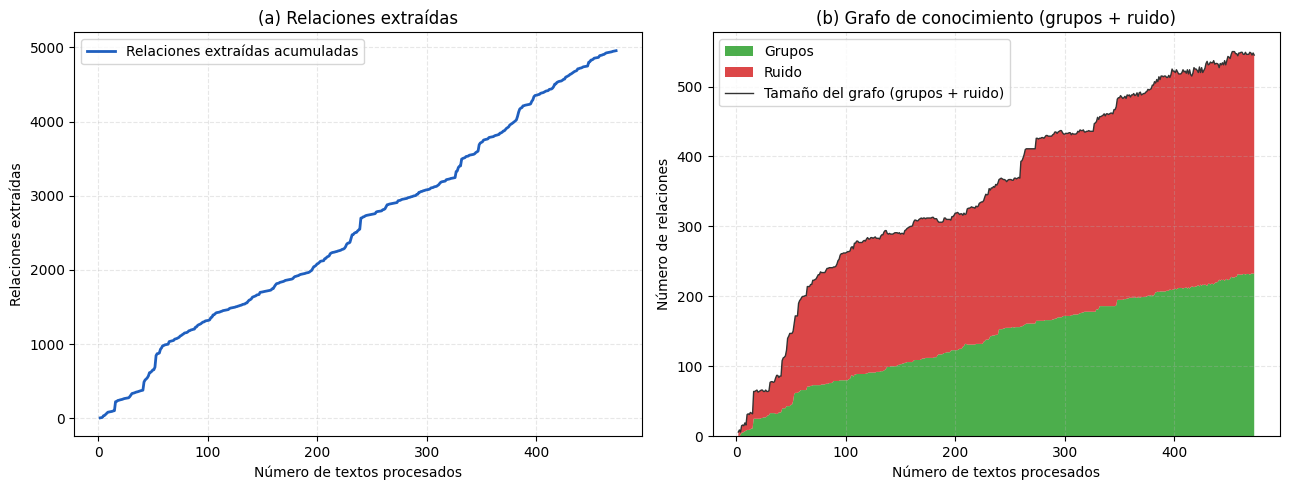

In [9]:
import matplotlib.pyplot as plt

x = df_resultados_iteraciones["iteration"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: relaciones extraídas ---
ax1.plot(x, df_resultados_iteraciones["total_relaciones"],
         linewidth=2, color="#1f5fbf", label="Relaciones extraídas acumuladas")
ax1.set_xlabel("Número de textos procesados")
ax1.set_ylabel("Relaciones extraídas")
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.legend(loc="upper left")
ax1.set_title("(a) Relaciones extraídas")

# --- Panel derecho: evolución del grafo de conocimiento (apilado) ---
ax2.stackplot(
    x,
    df_resultados_iteraciones["total_clusters"],
    df_resultados_iteraciones["total_noise"],
    labels=["Grupos", "Ruido"],
    colors=["#2ca02c", "#d62728"],
    alpha=0.85
)
ax2.plot(x, df_resultados_iteraciones["total_relaciones_kg"],
         linewidth=1, color="#333333", label="Tamaño del grafo (grupos + ruido)")
ax2.set_xlabel("Número de textos procesados")
ax2.set_ylabel("Número de relaciones")
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend(loc="upper left")
ax2.set_title("(b) Grafo de conocimiento (grupos + ruido)")

plt.tight_layout()
plt.savefig("exp5_evolucion.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# ============================================================
# INSPECCIÓN DE CLUSTERS
# ============================================================
# Mostramos las relaciones agrupadas en cada cluster
# para analizar coherencia semántica.

# Método para guardar en un fichero los resultados de la iteración
# Cuando se llama a escribir_log con limpiar=True se vacia el log de la pantalla
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = (
    f"{OUTPUT_DIR}/log_mrebel_exp08_inspection_clusters_{timestamp}.txt"
)
def escribir_log(texto , limpiar=False):
    
    if limpiar:
        clear_output(wait=True)

    print(texto)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(texto + "\n")



for cluster_id in sorted(df_triplets_final["cluster"].unique()):

    # Ignoramos ruido
    if cluster_id == -1:
        continue

    escribir_log("=" * 60, limpiar=True)
    escribir_log(f"CLUSTER {cluster_id}")
    escribir_log("=" * 60)

    cluster_data = df_triplets_final[
        df_triplets_final["cluster"] == cluster_id
    ]

    # relaciones_traductor = sorted(
    #     cluster_data["relation_es_translator_marks"].unique()
    # )


    #escribir_log(f"\nRelaciones traductor: {relaciones_traductor[:30]}")

    escribir_log(f"\nNúmero de relaciones: {len(cluster_data)}")
    #escribir_log(f"Número relaciones únicas traductor: {len(relaciones_traductor)}")

    escribir_log("\n")

CLUSTER 232

Número de relaciones: 6




In [10]:
pd.set_option("display.max_colwidth", None)


In [24]:
df_triplets_final[
    df_triplets_final["cluster"] == 14
][[
    "Frase",
    "relation",
    "head",
    "tail"

]]

,Frase,relation,head,tail
26,"Esta carta de pago se firmó en Madrid, desde d...",shares border with,Granada,Madrid
939,y que le enviarían diez carros de mulas para e...,shares border with,Oviedo,León
966,"Además, se acordó que Andrés de Melgosa escrib...",shares border with,Valladolid,Burgos
3123,En mayo de ese año Bernardo de la Vega (q. v.)...,shares border with,Antequera,Málaga
4496,"cada uno, serían para la compañía, excepto el ...",shares border with,Burgos,León
4497,"cada uno, serían para la compañía, excepto el ...",shares border with,León,Burgos


In [12]:
pd.reset_option("display.max_colwidth")

In [ ]:
# ============================================================
# MÉTRICAS BÁSICAS DE CLUSTERS
# ============================================================
# Calculamos métricas básicas para analizar el comportamiento
# de los clusters generados por HDBSCAN.

cluster_metrics = []

# Recorremos todos los clusters excepto ruido (-1).
for cluster_id in sorted(df_triplets_final["cluster"].unique()):

    if cluster_id == -1:
        continue

    cluster_data = df_triplets_final[
        df_triplets_final["cluster"] == cluster_id
    ]

    # Número total de relaciones en el cluster.
    total_relaciones_cluster = len(cluster_data)


     # Número de relaciones únicas.
    relaciones_unicas = cluster_data["relation"].nunique()

    # Frecuencia media de reutilización con traductor.
    frecuencia_media = (
        total_relaciones_cluster / relaciones_unicas
    )

    # Lista de relaciones del cluster.
    lista_relaciones = sorted(
        cluster_data["relation"].unique()
    )

    cluster_metrics.append({
        "cluster": cluster_id,
        "num_relaciones": total_relaciones_cluster,
        "num_relaciones_unicas": relaciones_unicas,
        "frecuencia_media": round(frecuencia_media, 2),
        "relaciones": ", ".join(lista_relaciones[:100])
    })

# Convertimos a dataframe.
df_cluster_metrics = pd.DataFrame(cluster_metrics)

# Ordenamos por tamaño del cluster.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="num_relaciones",
    ascending=False
).reset_index(drop=True)

print("Métricas de clusters calculadas correctamente.")

df_cluster_metrics.head(10)

Métricas de clusters calculadas correctamente.


,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones
0,87,419,1,419.0,spouse
1,204,350,1,350.0,part of
2,80,193,1,193.0,child
3,192,158,1,158.0,author
4,168,157,1,157.0,occupation
5,103,129,1,129.0,located in the administrative territorial entity
6,104,116,1,116.0,located in the administrative territorial entity
7,134,115,1,115.0,follows
8,100,104,1,104.0,located in the administrative territorial entity
9,119,101,1,101.0,sibling


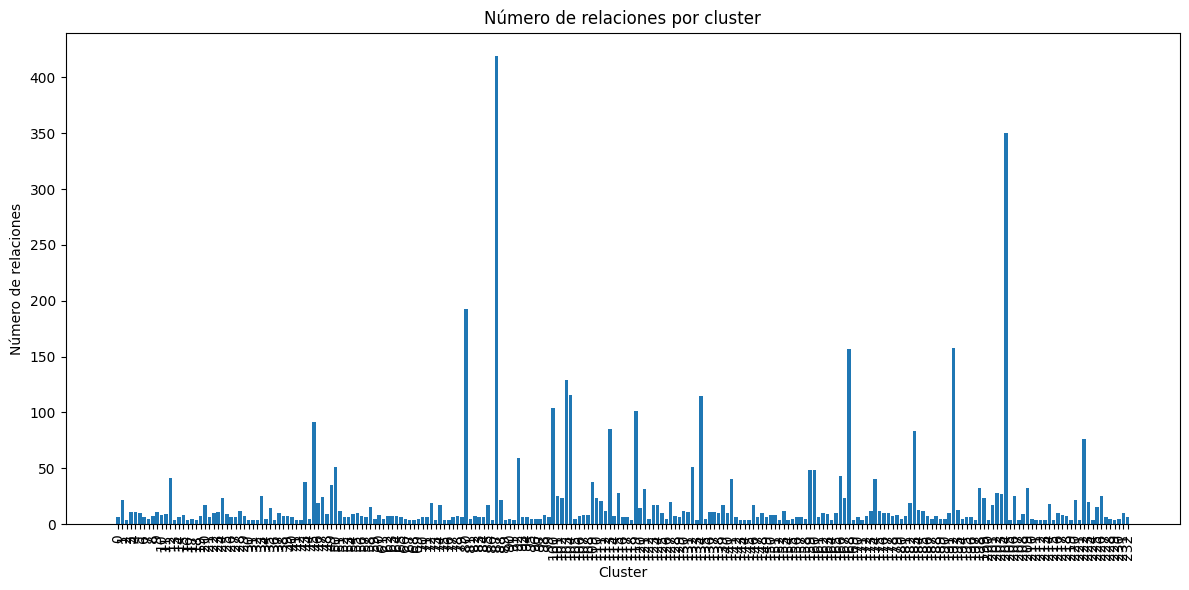

In [26]:
# ============================================================
# TAMAÑO DE LOS CLUSTERS
# ============================================================
# Visualización del número de relaciones detectadas
# en cada cluster generado por HDBSCAN.

# Ordenamos clusters por tamaño.
df_plot = df_cluster_metrics.sort_values(
    by="cluster",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    df_plot["cluster"].astype(str),
    df_plot["num_relaciones"]
)

plt.title("Número de relaciones por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de relaciones")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# COHERENCIA SEMÁNTICA INTRA-CLUSTER
# ============================================================
# Calculamos la similitud media entre los embeddings de cada cluster.
#
# Importante:
# Cada embedding se asocia explícitamente a su fila correspondiente
# para evitar desalineaciones entre índices del dataframe y posiciones
# del array de embeddings.

from sklearn.metrics.pairwise import cosine_similarity

# Guardamos cada embedding dentro del dataframe de relaciones.
# Esto garantiza que cada fila conserva su representación vectorial.

cluster_coherence = []

for cluster_id in sorted(df_triplets_final["cluster"].unique()):

    # Ignoramos el ruido.
    if cluster_id == -1:
        continue

    # Filtramos las relaciones pertenecientes al cluster actual.
    cluster_data = df_triplets_final[
        df_triplets_final["cluster"] == cluster_id
    ]

    # Recuperamos los embeddings asociados a esas filas.
    cluster_embeddings = np.vstack(
        cluster_data["embedding"].values
    )

    # Si el cluster tiene menos de 2 elementos, no se puede calcular coherencia.
    if len(cluster_embeddings) < 2:
        coherence = np.nan
    else:
        sim_matrix = cosine_similarity(cluster_embeddings)

        # Extraemos solo la parte superior de la matriz, excluyendo la diagonal.
        # Así evitamos comparar cada embedding consigo mismo.
        sim_values = sim_matrix[
            np.triu_indices_from(sim_matrix, k=1)
        ]

        coherence = sim_values.mean()

    cluster_coherence.append({
        "cluster": cluster_id,
        "coherencia_semantica": coherence
    })

df_cluster_coherence = pd.DataFrame(cluster_coherence)

# Eliminamos una posible columna previa de coherencia si la celda se reejecuta.
df_cluster_metrics = df_cluster_metrics.drop(
    columns=["coherencia_semantica"],
    errors="ignore"
)

# Unimos la coherencia con las métricas básicas de cluster.
df_cluster_metrics = df_cluster_metrics.merge(
    df_cluster_coherence,
    on="cluster",
    how="left"
)

# Ordenamos por coherencia semántica.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="coherencia_semantica",
    ascending=True
).reset_index(drop=True)

df_cluster_metrics.head(15)


,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones,coherencia_semantica
0,38,7,4,1.75,"follows, is a list of, main subject, part of",0.789815
1,9,11,1,11.00,currency,0.797056
2,54,9,9,1.00,"author <concept> 1968 <date> publication date,...",0.802164
3,37,10,8,1.25,place of birth <per> Feliciana de Andrade <per...,0.807865
4,68,4,2,2.00,"occupant, participant",0.834718
5,55,10,2,5.00,collection <concept> 14 de mayo de 1706 <date>...,0.836431
6,164,4,4,1.00,"author <org> Antonio de Andrada <per> author, ...",0.849447
7,52,6,2,3.00,"award received, award received <per> DM <org> ...",0.853837
8,179,8,7,1.14,"author <concept> José de Prado <per> author, a...",0.879913
9,106,7,3,2.33,"creator, discoverer or inventor, discoverer or...",0.898757


In [28]:
df_cluster_metrics.head(15)
#df_cluster_metrics.tail(15)

,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones,coherencia_semantica
0,38,7,4,1.75,"follows, is a list of, main subject, part of",0.789815
1,9,11,1,11.00,currency,0.797056
2,54,9,9,1.00,"author <concept> 1968 <date> publication date,...",0.802164
3,37,10,8,1.25,place of birth <per> Feliciana de Andrade <per...,0.807865
4,68,4,2,2.00,"occupant, participant",0.834718
5,55,10,2,5.00,collection <concept> 14 de mayo de 1706 <date>...,0.836431
6,164,4,4,1.00,"author <org> Antonio de Andrada <per> author, ...",0.849447
7,52,6,2,3.00,"award received, award received <per> DM <org> ...",0.853837
8,179,8,7,1.14,"author <concept> José de Prado <per> author, a...",0.879913
9,106,7,3,2.33,"creator, discoverer or inventor, discoverer or...",0.898757


In [29]:
# ============================================================
# BUSQUEDA PARA CADA CLUSTER DEL MEDOID
# ============================================================

## eL MEDOID ES el embedding cuya distancia media al resto es mínima

import numpy as np
from sklearn.metrics.pairwise import cosine_distances


def assign_cluster_medoids(df_triplets_final):
    """
    Añade una columna 'relation_elected' al dataframe.
    
    - 'SI'  -> relación medoid del cluster
    - 'NO'  -> resto de relaciones del cluster
    - ruido (-1) -> siempre 'SI'
    
    Requiere:
    - columna 'embedding'
    - columna 'cluster'
    """

    # Inicializar columna
    df_triplets_final["relation_elected"] = "NO"

    # Obtener clusters únicos
    clusters = df_triplets_final["cluster"].unique()

    for cluster_id in clusters:

        # Caso ruido
        if cluster_id == -1:
            df_triplets_final.loc[
                df_triplets_final["cluster"] == -1,
                "relation_elected"
            ] = "SI"

            continue

        # Filas del cluster
        cluster_df = df_triplets_final[
            df_triplets_final["cluster"] == cluster_id
        ]

        # Obtener embeddings
        embeddings = np.array(
            cluster_df["embedding"].tolist()
        )

        # Calcular matriz de distancias coseno
        dist_matrix = cosine_distances(embeddings)

        # Distancia media de cada embedding al resto
        avg_distances = dist_matrix.mean(axis=1)

        # Índice del medoid (mínima distancia media)
        medoid_local_idx = np.argmin(avg_distances)

        # Índice real dentro del dataframe original
        medoid_global_idx = cluster_df.index[medoid_local_idx]

        # Marcar medoid como SI
        df_triplets_final.loc[
            medoid_global_idx,
            "relation_elected"
        ] = "SI"

    return df_triplets_final

df_triplets_final = assign_cluster_medoids(df_triplets_final)

In [30]:
num_relations_selected = (
    df_triplets_final["relation_elected"] == "SI"
).sum()

print(num_relations_selected)

545


In [31]:
df_triplets_final.columns

Index(['id', 'Nombre', 'Anyo', 'Frase', 'head', 'head_type', 'tail',
       'tail_type', 'relation', 'head_type_full', 'tail_type_full',
       'texto_embedding', 'embedding', 'cluster', 'relation_elected'],
      dtype='object')

In [32]:
# Método para guardar en un fichero los resultados de la iteración
# Cuando se llama a escribir_log con limpiar=True se vacia el log de la pantalla
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = (
    f"{OUTPUT_DIR}/log_mrebel_exp08_inspeccion_clusters_medoids_{timestamp}.txt"
)
def escribir_log(texto , limpiar=False):
    
    if limpiar:
        clear_output(wait=True)

    print(texto)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(texto + "\n")


for cluster_id in sorted(df_triplets_final["cluster"].unique()):

    # Ignorar ruido
    if cluster_id == -1:
        continue

    escribir_log("=" * 60, limpiar=True)
    escribir_log(f"CLUSTER {cluster_id}")
    escribir_log("=" * 60)

    # Datos del cluster
    cluster_data = df_triplets_final[
        df_triplets_final["cluster"] == cluster_id
    ]

    # Relaciones únicas
    # relaciones_traductor = sorted(
    #     cluster_data["relation_es_translator_marks"].unique()
    # )

    # Relación elegida (medoid)
    relacion_elegida = cluster_data[
        cluster_data["relation_elected"] == "SI"
    ]

    # Mostrar relaciones agrupadas
    #print(f"\nRelaciones traductor: {relaciones_traductor[:30]}")

    # Mostrar relación elegida
    escribir_log("\nRelación elegida:")

    for _, row in relacion_elegida.iterrows():

        escribir_log(
            f"- {row['head_type_full']} -- "
            f"{row['relation']} -- "
            f"{row['tail_type_full']} "
            #f"| traductor: {row['relation_es_translator_marks']} "

        )

    # Estadísticas
    escribir_log(f"\nNúmero de relaciones: {len(cluster_data)}")

    #print(
    #    f"Número relaciones únicas traductor: "
    #    f"{len(relaciones_traductor)}"
    #)



    escribir_log("\n")

CLUSTER 232

Relación elegida:
- organization -- part of -- organization 

Número de relaciones: 6


